<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [4]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [6]:
## Write your code here
# count number of duplicate rows in dataframe
duplicate_count = df.duplicated().sum()
print(f'The number of duplicate rows in the dataset is {duplicate_count}')
#drop duplicates using drop_duplicates() function
df.drop_duplicates(inplace=True) #inplace=true keeps it in the same dataframe
duplicate_count = df.duplicated().sum()
print(f'The number of duplicate rows in the dataset is {duplicate_count}')

The number of duplicate rows in the dataset is 0
The number of duplicate rows in the dataset is 0


### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [7]:
## Write your code here
missing_values = df['CodingActivities'].isna().sum() #find number of missing rows in column CodingActivities
print(f'The number of missing rows in column CodingActivities is {missing_values}')

The number of missing rows in column CodingActivities is 10971


##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [8]:
## Write your code here
#impute missing values using forward-fill
df['CodingActivities']=df['CodingActivities'].ffill()
missing_values = df['CodingActivities'].isna().sum() #find number of missing rows in column CodingActivities
print(f'The number of missing rows in column CodingActivities is {missing_values}')

The number of missing rows in column CodingActivities is 0


**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [19]:
## Write your code here
# List all columns containing the string "Comp"
comp_columns = [col for col in df.columns if 'Comp' in col]
print(f"Compensation-related columns: {comp_columns}")

missing_values = df['ConvertedCompYearly'].isna().sum() #find number of missing rows in column ConvertedCompYearly
print(f'The original number of missing rows in column ConvertedCompYearly is {missing_values}')

df_clean = df.dropna(subset=['ConvertedCompYearly'])
missing_values2 = df_clean['ConvertedCompYearly'].isna().sum() #find number of missing rows in column ConvertedCompYearly
print(f'The number of missing rows in column ConvertedCompYearly is now {missing_values2} in df_clean')

Compensation-related columns: ['CompTotal', 'AIComplex', 'ConvertedCompYearly', 'ConvertedCompYearly_MinMax', 'ConvertedCompYearly_Zscore']
The original number of missing rows in column ConvertedCompYearly is 42002
The number of missing rows in column ConvertedCompYearly is now 0 in df_clean


##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [20]:
## Write your code here
#Calculate minimum and maximum values of ConvertedCompYearly
min_comp = df_clean['ConvertedCompYearly'].min()
max_comp = df_clean['ConvertedCompYearly'].max()
print(f'the original minimum comp is {min_comp} and the original maximum comp is {max_comp}')

df['ConvertedCompYearly_MinMax'] = (df_clean['ConvertedCompYearly'] - min_comp)/(max_comp - min_comp)
print(f'New normalized MinMax : {df_clean['ConvertedCompYearly_MinMax'].min()} to {df_clean['ConvertedCompYearly_MinMax'].max()}')

the original minimum comp is 1.0 and the original maximum comp is 16256603.0
New normalized MinMax : 0.0 to 1.0


##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [38]:
## Write your code here

# Z-score formula is (x-mean)/std, need to calculate those first
mean_comp =df_clean['ConvertedCompYearly'].mean()
std_comp = df_clean['ConvertedCompYearly'].std()

#calculate Z-score
df['ConvertedCompYearly_Zscore'] = (df_clean['ConvertedCompYearly'] - mean_comp)/ std_comp

#check Z-scores
print(df_clean[['ConvertedCompYearly', 'ConvertedCompYearly_Zscore']].tail())


       ConvertedCompYearly  ConvertedCompYearly_Zscore
41180              44640.0                   -0.222296
41184             170000.0                    0.448951
41185             116844.0                    0.164324
41186              12000.0                   -0.397068
41187             222834.0                    0.731853


<bound method NDFrame.describe of        ConvertedCompYearly  ConvertedCompYearly_Zscore  \
72                  7322.0                   -0.422117   
374                30074.0                   -0.300290   
379                91295.0                    0.027521   
385                53703.0                   -0.173767   
389               110000.0                    0.127678   
...                    ...                         ...   
41180              44640.0                   -0.222296   
41184             170000.0                    0.448951   
41185             116844.0                    0.164324   
41186              12000.0                   -0.397068   
41187             222834.0                    0.731853   

       ConvertedCompYearly_MinMax  
72                       0.000450  
374                      0.001850  
379                      0.005616  
385                      0.003303  
389                      0.006766  
...                           ...  
41180            

In [40]:
df_clean[['ConvertedCompYearly', 'ConvertedCompYearly_Zscore', 'ConvertedCompYearly_MinMax']].dtypes


ConvertedCompYearly           float64
ConvertedCompYearly_Zscore    float64
ConvertedCompYearly_MinMax    float64
dtype: object

### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


Text(0.5, 0, 'Normalized Annual Salary')

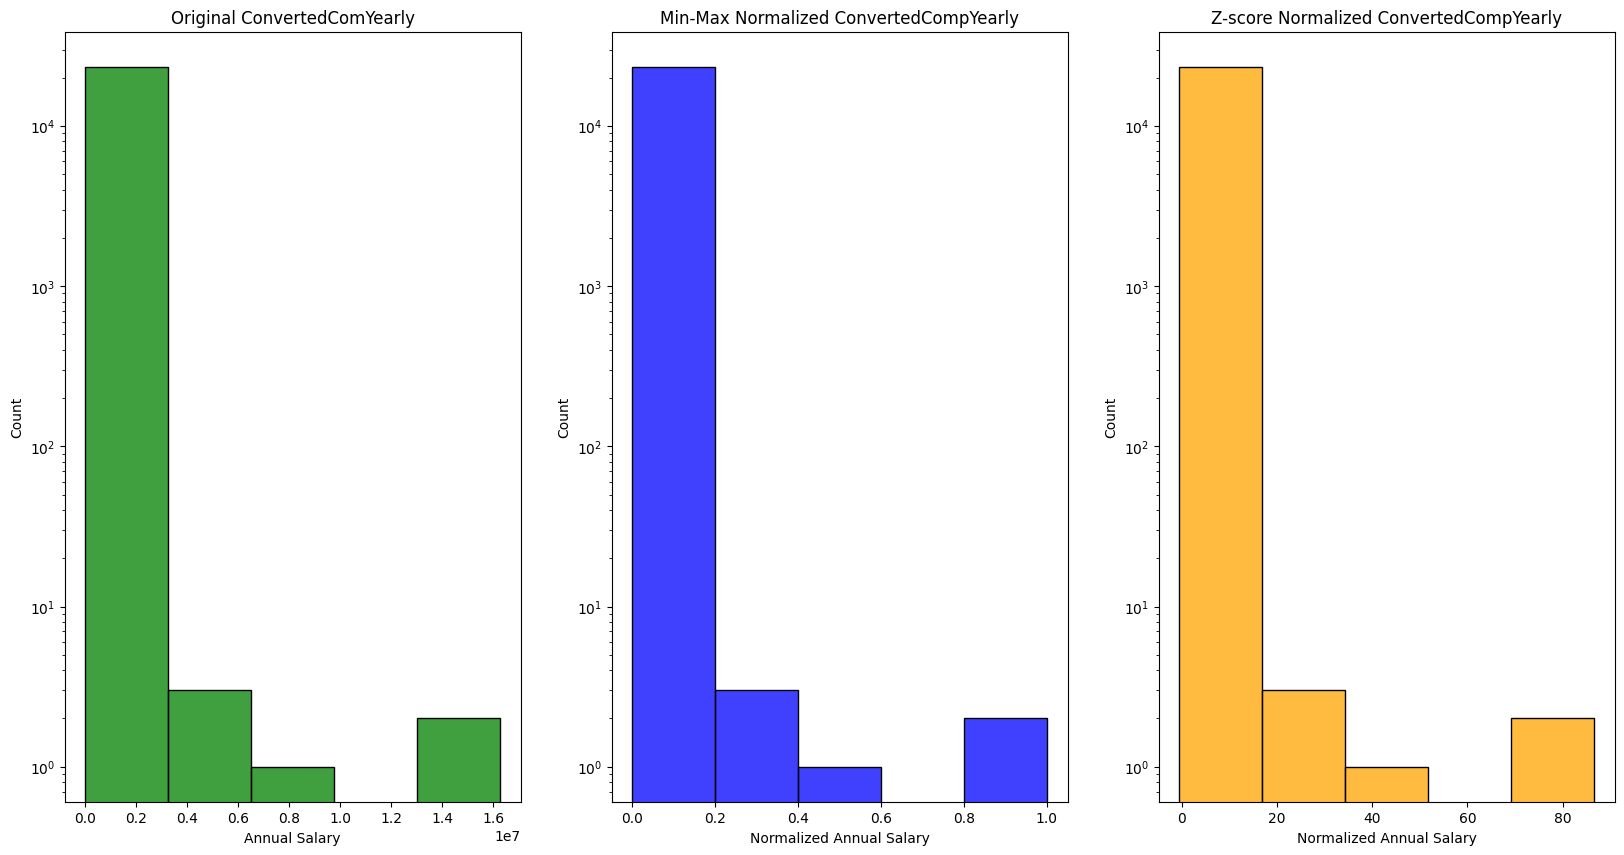

In [43]:
## Write your code here
import seaborn as sns
#Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize =(20, 10))

#plot Original data
sns.histplot(df_clean['ConvertedCompYearly'], bins=5, ax=axes[0], log=True, color='green')
axes[0].set_title('Original ConvertedComYearly')
axes[0].set_xlabel('Annual Salary')

#plot Min-Max Normalized Data
sns.histplot(df_clean['ConvertedCompYearly_MinMax'], bins = 5, ax =axes[1], log=True, color='blue')
axes[1].set_title('Min-Max Normalized ConvertedCompYearly')
axes[1].set_xlabel('Normalized Annual Salary')

#plot Z-score Normalized Data
sns.histplot(df_clean['ConvertedCompYearly_Zscore'], bins = 5, ax =axes[2], log=True, color='orange')
axes[2].set_title('Z-score Normalized ConvertedCompYearly')
axes[2].set_xlabel('Normalized Annual Salary')




### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
